# FABN — Size of the Prize (Perfect-Foresight Upper Bound)

**Question (from the McKinsey review):** if we knew the next two years of prices **perfectly**, what is
the maximum cumulative SAP / NII we could earn — carry **plus** realized trading gains, net of
bid-ask/2 cost — by trading as much as it's worth? This is a **ceiling**, not a strategy. The **gap**
to the realistic dynamic backtest is the *size of the prize*: it tells us whether smarter trading has
upside worth building.

Method: a time-expanded **trade-arc LP** (see `prize_theory.md`). Each arc *(bond, buy date, close
date)* has a constant per-dollar profit under foresight; we conserve **book value** (realized gains
never become redeployable principal — the anti-liquidation discipline) under the same duration / issuer
/ facility constraints as the optimizer.

**Prereq:** run `FABN_Optimizer_SAP_Backtest.ipynb` through its Section-1 precompute + the
`export_panels()` cell to produce `prize_panels.npz` (one shared source of truth — no silent
divergence). Gurobi WLS + GCP ADC are *not* needed here; only Gurobi to solve.

In [2]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.dirname(os.getcwd()))   # Optimization/ on path -> fabn_finance
import prize_foresight as pf
import fabn_finance as ff

# --- Gurobi license -------------------------------------------------------
# The arc LP is large (~50k vars); the free size-limited license caps at 2000.
# Load the repo-root .env WLS credentials so Gurobi uses the unlimited license
# (the daily backtest never needed this — its per-solve model fits the free cap).
_creds = pf.load_dotenv_creds()                 # WLS creds from repo-root .env (used only if needed)
GENV, LIC_KIND = pf.make_gurobi_env(_creds)     # prefers a working academic/full license
print(f"Gurobi license in use: {LIC_KIND}")
if LIC_KIND == "size-limited":
    print("  NOTE: only the FREE 2000-variable license is active. The full arc model is larger.\n"
          "  -> Renew your academic license (creates ~/gurobi.lic), then re-run; OR set MAX_BONDS\n"
          "     (e.g. 70) + a coarse grid below to fit the free cap for a directional read.")

PANELS = "prize_panels.npz"
assert os.path.exists(PANELS), (
    "prize_panels.npz not found — run the export_panels() cell in "
    "FABN_Optimizer_SAP_Backtest.ipynb first.")
z = np.load(PANELS, allow_pickle=True)
Y, DUR, TAU, MID = z["Y"], z["DUR"], z["TAU"], z["MID"]
ELIG, ALIVE = z["ELIG"], z["ALIVE"]
THETA = z["THETA"]
CUSIPS = list(z["CUSIPS"])
BT_DATES = pd.DatetimeIndex(z["BT_DATES_ns"].astype("datetime64[ns]"))
MATURITY = pd.DatetimeIndex(z["MATURITY_ns"].astype("datetime64[ns]"))
QB, FB = z["QB"], z["FB"]
ALLQ = pd.PeriodIndex([pd.Period(s) for s in z["ALLQ"]])
H = float(z["H"]); r_FABN = float(z["r_FABN"])
FABN_MATURITY = pd.Timestamp(np.datetime64(int(z["FABN_MATURITY_ns"]), "ns"))
FABN_ISSUE = pd.Timestamp("2022-09-06")   # constant; only relative CF timing matters for D_FABN

nD, N = Y.shape
date0 = BT_DATES[0]
YEAR = 365.25
t_days = (BT_DATES - date0).days.values / YEAR              # years from start, per daily index
t_mat = (MATURITY - date0).days.values / YEAR               # per-bond maturity in years
window_end = t_days[-1]
fabn_mat_yr = (FABN_MATURITY - date0).days / YEAR

# --- Optional LITE universe cap (only needed without WLS) ------------------
# Keep the MAX_BONDS highest mean-book-yield *eligible* bonds so the model fits
# the free 2000-var license. None = full universe (requires WLS). A capped
# universe under-states the prize (fewer bonds to rotate among) — directional only.
MAX_BONDS = None
if MAX_BONDS is not None and MAX_BONDS < N:
    _score = np.where(ELIG.any(axis=0), np.nanmean(np.where(ELIG, Y, np.nan), axis=0), -np.inf)
    KEEP = np.sort(np.argsort(_score)[::-1][:MAX_BONDS])
    Y, DUR, TAU, MID = Y[:, KEEP], DUR[:, KEEP], TAU[:, KEEP], MID[:, KEEP]
    ELIG, ALIVE = ELIG[:, KEEP], ALIVE[:, KEEP]
    THETA, t_mat = THETA[KEEP], t_mat[KEEP]
    CUSIPS = [CUSIPS[i] for i in KEEP]; QB = QB[:, KEEP]; N = len(KEEP)
    print(f"LITE universe: kept {N} bonds (highest mean book yield)")

issuer_groups = {}
for i, c in enumerate(CUSIPS):
    issuer_groups.setdefault(str(c)[:6], []).append(i)
print(f"panels: {nD} dates x {N} bonds | {date0.date()} -> {BT_DATES[-1].date()} "
      f"({window_end:.2f}y) | FABN matures {FABN_MATURITY.date()}")

Gurobi license in use: wls
panels: 498 dates x 303 bonds | 2024-03-01 -> 2026-02-26 (1.99y) | FABN matures 2027-09-06


## Parameters (mirror the backtest `PARAMS`)

In [3]:
PARAMS = dict(
    cost_of_capital=0.15, RBC_bar=1.5,   # lambda = 0.225 on required capital
    eps_D=0.30, dur_pen=1.0,             # soft duration band (years) + breach penalty
    delta_iss=0.05,                      # issuer concentration cap (fraction of H)
    r_save=r_FABN, r_borrow=0.05, phi_sf=0.01,   # lending facility
    allow_post_fabn=True,
)
LAMBDA = PARAMS["cost_of_capital"] * PARAMS["RBC_bar"]
print("lambda =", LAMBDA)

lambda = 0.22499999999999998


## Grid, FABN duration, and per-grid solver inputs

Trades happen on a coarse rebalance grid (default monthly); carry accrues daily between nodes. A
coarser grid offers fewer trade chances, so it **under-states** the prize — the safe direction.

In [4]:
def build_grid(freq="MS"):
    """Daily-index rebalance grid: first available trading day of each period."""
    s = pd.Series(np.arange(nD), index=BT_DATES)
    idx = s.groupby(BT_DATES.to_period({"MS": "M", "2W": "W"}.get(freq, "M")
                    if freq in ("MS",) else ("W" if "W" in freq else "M"))).first().values
    grid = np.unique(np.concatenate([[0], idx, [nD - 1]]))
    return grid.astype(int)

def build_grid_every(step_days_idx):
    """Alternative: every k-th trading day (k in index units)."""
    grid = np.unique(np.concatenate([np.arange(0, nD, step_days_idx), [nD - 1]]))
    return grid.astype(int)

def d_fabn_at(date):
    """Modified duration of the remaining FABN liability at `date` (matches quarter_slice)."""
    sd = pd.DatetimeIndex([FABN_ISSUE + pd.DateOffset(months=6 * k) for k in range(1, 11)])
    tot = np.full(len(sd), r_FABN / 2 * 100.0); tot[-1] += 100.0
    fut = sd > date
    if not fut.any():
        return 0.0
    tt = (sd[fut] - date).days.values / YEAR
    cf = tot[fut.nonzero()[0]] if hasattr(fut, "nonzero") else tot[np.array(fut)]
    cf = tot[np.where(fut)[0]]
    return float((tt * cf).sum() / cf.sum() / (1.0 + r_FABN / 2))

def make_inputs(grid):
    """Build DUR_grid, d_fabn_grid, and the quarterly facility dict for a grid."""
    P = len(grid)
    t_grid = t_days[grid]
    DUR_grid = DUR[grid, :]                                  # (P, N) modified duration per interval
    d_fabn_grid = np.array([d_fabn_at(BT_DATES[g]) for g in grid])
    # facility over IN-WINDOW quarters only: holdings exist only within the
    # measurement window, so (like the backtest's horizon) we fund the liability
    # cashflows that fall inside it. The post-window final principal is out of scope.
    q0 = ALLQ.get_loc(date0.to_period("Q"))
    q1 = ALLQ.get_loc(BT_DATES[-1].to_period("Q"))
    qsl = slice(q0, q1 + 1)
    QB_q, FB_q = QB[qsl], FB[qsl]
    quarters = ALLQ[qsl]
    qstart = pd.PeriodIndex(quarters).to_timestamp()        # quarter start dates
    # map each quarter to the grid interval whose holdings drive it
    grid_dates = BT_DATES[grid]
    q_interval = np.clip(np.searchsorted(grid_dates.values, qstart.values, side="right") - 1, 0, P - 1)
    Qn = len(FB_q)
    df = np.array([(1.0 + r_FABN) ** (-(0.25 * (k + 1))) for k in range(Qn)])
    PV_L = float((FB_q * df).sum())
    facility = dict(QB_q=QB_q, FB_q=FB_q, q_interval=q_interval, df=df, PV_L=PV_L,
                    r_save=PARAMS["r_save"], r_borrow=PARAMS["r_borrow"],
                    phi_sf=PARAMS["phi_sf"], dt_q=0.25)
    return dict(P=P, t_grid=t_grid, DUR_grid=DUR_grid, d_fabn_grid=d_fabn_grid, facility=facility)

## Solve — headline prize (monthly grid)

We solve twice on the same grid: the full foresight optimum (**prize**) and a foresight **static**
floor (`buy_nodes={0}` — pick the best day-0 book knowing the future, but never trade after). The
prize must be ≥ the static floor (it is a strict superset of feasible solutions) — asserted below.

In [5]:
def run_grid(grid, with_facility=False, enforce=True):
    inp = make_inputs(grid)
    common = dict(grid=grid, t_grid=inp["t_grid"], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU,
                  THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
                  fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS["allow_post_fabn"])
    arcs_dyn = pf.build_arcs(**common)
    arcs_sta = pf.build_arcs(**common, buy_nodes={0})
    sv = dict(H=H, P=inp["P"], N=N, DUR_grid=inp["DUR_grid"], d_fabn_grid=inp["d_fabn_grid"],
              issuer_groups=issuer_groups, eps_D=PARAMS["eps_D"], dur_pen=PARAMS["dur_pen"],
              delta_iss=PARAMS["delta_iss"], enforce_duration=enforce, enforce_issuer=enforce,
              facility=inp["facility"] if with_facility else None, env=GENV)
    dyn = pf.solve_prize(arcs_dyn, **sv)
    sta = pf.solve_prize(arcs_sta, **sv)
    return dyn, sta, arcs_dyn

grid_m = build_grid("MS")
print(f"monthly grid: {len(grid_m)} nodes")
dyn, sta, arcs_dyn = run_grid(grid_m)
print(f"arcs: {arcs_dyn['n_arcs']:,}")
for r, lbl in [(sta, "static"), (dyn, "dynamic")]:
    assert r["status"] == "OPTIMAL", f"{lbl} solve not OPTIMAL: {r['status']} (check facility feasibility)"

def show(res, label):
    d = res["decomp"]
    print(f"{label:28s} window=${res['prize_window']/1e6:8.2f}M  full=${res['prize_full']/1e6:8.2f}M")
    print(f"{'':28s}  carry=${d['carry']/1e6:.2f}M  cap=-${d['capital']/1e6:.2f}M  "
          f"cost=-${d['cost']/1e6:.2f}M  imr_win=${d['imr_window']/1e6:.2f}M  "
          f"imr_full=${d['imr_full']/1e6:.2f}M  fac=${d.get('facility',0)/1e6:.2f}M")

show(sta, "Foresight STATIC (floor)")
show(dyn, "Foresight DYNAMIC (prize)")
gap = dyn["prize_window"] - sta["prize_window"]
print(f"\nPRIZE GAP (dynamic - static, windowed) = ${gap/1e6:.2f}M  "
      f"({100*gap/abs(sta['prize_window']):.1f}% of static)")

# Upper-bound sanity: the prize is a superset of the static feasible set.
assert dyn["prize_window"] >= sta["prize_window"] - 1.0, "BUG: prize below its own static floor!"

monthly grid: 25 nodes
arcs: 88,012
Foresight STATIC (floor)     window=$   29.05M  full=$   29.05M
                              carry=$32.66M  cap=-$2.86M  cost=-$0.76M  imr_win=$0.00M  imr_full=$0.00M  fac=$0.00M
Foresight DYNAMIC (prize)    window=$   41.99M  full=$   62.26M
                              carry=$32.93M  cap=-$2.42M  cost=-$4.80M  imr_win=$16.27M  imr_full=$36.54M  fac=$0.00M

PRIZE GAP (dynamic - static, windowed) = $12.94M  (44.6% of static)


## Compare to the realistic backtest

Paste the backtest's cumulative-net numbers (printed by `FABN_Optimizer_SAP_Backtest.ipynb`). Defaults
are the documented placeholder results. The prize should sit **above** both — if not, investigate.

In [6]:
STATIC_REF  = 27.76e6     # backtest static baseline (CumNet)
DYNAMIC_REF = 31.0e6      # backtest best tuned dynamic (reopt_every~21, kappa~2-5); update from your run

print(f"backtest static  : ${STATIC_REF/1e6:.2f}M")
print(f"backtest dynamic : ${DYNAMIC_REF/1e6:.2f}M  (realistic, no foresight)")
print(f"PRIZE (window)   : ${dyn['prize_window']/1e6:.2f}M")
print(f"PRIZE (full IMR) : ${dyn['prize_full']/1e6:.2f}M")
headroom = dyn["prize_window"] - DYNAMIC_REF
print(f"\nHEAD-ROOM vs realistic dynamic = ${headroom/1e6:.2f}M "
      f"({100*headroom/DYNAMIC_REF:.1f}%)  <- the 'size of the prize'")
if dyn["prize_window"] < DYNAMIC_REF:
    print("WARNING: prize below realistic dynamic — grid too coarse or a modeling issue; "
          "refine the grid (next section) and re-check.")

backtest static  : $27.76M
backtest dynamic : $31.00M  (realistic, no foresight)
PRIZE (window)   : $41.99M
PRIZE (full IMR) : $62.26M

HEAD-ROOM vs realistic dynamic = $10.99M (35.4%)  <- the 'size of the prize'


## Optional: tighten with the lending-facility / PV-shortfall constraint

The headline already forbids the liquidation trick (book value is conserved — realized gains never
become redeployable principal). This cell adds the **quarterly facility recursion + 1% PV-shortfall
cap** (the liquidity guardrail) as a further tightening. The hard cap can be infeasible on edge data
(a near-term FABN coupon with thin same-quarter inflow), so we **fall back** to the headline and warn
rather than crash — the headline remains a valid ceiling either way.

In [7]:
dyn_fac, sta_fac, _ = run_grid(build_grid('MS'), with_facility=True)
if dyn_fac['status'] == 'OPTIMAL' and sta_fac['status'] == 'OPTIMAL':
    show(dyn_fac, 'Prize WITH facility')
    print(f"borrowing cost charged = ${-dyn_fac['decomp']['facility']/1e6:.2f}M")
    assert dyn_fac['prize_window'] <= dyn['prize_window'] + 1.0, \
        'facility should only tighten (lower) the prize'
else:
    print(f"facility solve not optimal (dyn={dyn_fac['status']}, sta={sta_fac['status']}) "
          f"-> shortfall cap infeasible on this data; headline (facility-off) ceiling stands.")

Prize WITH facility          window=$   41.95M  full=$   62.10M
                              carry=$33.01M  cap=-$2.43M  cost=-$4.84M  imr_win=$16.22M  imr_full=$36.37M  fac=$-0.00M
borrowing cost charged = $0.00M


## Grid-sensitivity sweep

The prize should **rise then plateau** as the grid refines (more trade opportunities), confirming the
coarse-grid number is a conservative bound, not an artifact of one grid.

,grid,nodes,arcs,prize_window_M,prize_full_M,static_M
0,quarterly,9,10505,36.207299,45.444322,29.045857
1,monthly,25,88012,41.987089,62.258622,29.045857
2,biweekly,51,374419,47.071569,80.603220,29.045857
3,weekly,101,1483305,54.002524,106.291289,29.037050


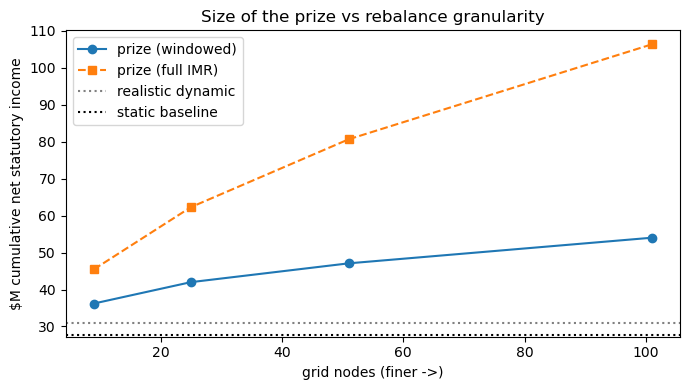

In [8]:
rows = []
for label, grid in [("quarterly", build_grid_every(63)),
                    ("monthly",   build_grid("MS")),
                    ("biweekly",  build_grid_every(10)),
                    ("weekly",    build_grid_every(5))]:
    d, s, a = run_grid(grid)
    rows.append(dict(grid=label, nodes=len(grid), arcs=a["n_arcs"],
                     prize_window_M=d["prize_window"]/1e6, prize_full_M=d["prize_full"]/1e6,
                     static_M=s["prize_window"]/1e6))
sweep = pd.DataFrame(rows)
display(sweep)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(sweep["nodes"], sweep["prize_window_M"], "o-", label="prize (windowed)")
ax.plot(sweep["nodes"], sweep["prize_full_M"], "s--", label="prize (full IMR)")
ax.axhline(DYNAMIC_REF/1e6, color="grey", ls=":", label="realistic dynamic")
ax.axhline(STATIC_REF/1e6, color="black", ls=":", label="static baseline")
ax.set_xlabel("grid nodes (finer ->)"); ax.set_ylabel("$M cumulative net statutory income")
ax.set_title("Size of the prize vs rebalance granularity"); ax.legend(); plt.tight_layout(); plt.show()

## Constraint-relaxed loose ceiling (context)

Drop the duration / issuer / facility constraints: a looser, larger upper bound. The headline prize
should sit **below** this. It frames how much of the foregone upside is blocked by the regulatory /
ALM constraints themselves vs by the lack of foresight.

In [9]:
dyn_loose, _, _ = run_grid(build_grid("MS"), with_facility=False, enforce=False)
print(f"loose ceiling (no duration/issuer/facility) = ${dyn_loose['prize_window']/1e6:.2f}M")
print(f"headline prize (all constraints)            = ${dyn['prize_window']/1e6:.2f}M")
assert dyn_loose["prize_window"] >= dyn["prize_window"] - 1.0, "BUG: constrained prize above loose ceiling!"

loose ceiling (no duration/issuer/facility) = $60.48M
headline prize (all constraints)            = $41.99M


## How to read this / limitations

- **Head-room = prize − realistic dynamic** is the *size of the prize*. Large ⇒ tradeable upside worth
  building toward; small ⇒ value is mostly static carry.
- The **decomposition** shows the prize is carry-timing (not a price-flipping mirage — IMR amortization
  neutralizes pure gains trading by design).
- **Ceiling, not a strategy:** perfect foresight is unattainable.
- **No market impact:** "trade a lot" is modeled at bid-ask/2 with infinite liquidity → the ceiling is
  *optimistic*; a desk trading size pays more. Capacity/impact modeling is the next extension.
- **Coarse grid under-states** the prize (the sweep shows the plateau). Clean prices; **AVR excluded**
  (rate-driven IMR only). Quarterly facility timing, as in the backtest.

## Optional (heavy): DAILY rebalancing on the full universe — the extreme ceiling

True *unrestricted* daily × all 303 bonds is intractable (~37M arcs, ~100 GB). We approximate it
with a **max-hold cap `L`**: a bond is flipped within `L` trading days **or** held to the terminal
close, which makes arc growth `O(N·P·L)` instead of `O(N·P²)`. Larger `L` → closer to unrestricted
daily → bigger (and less realistic) number.

**WARNING — read `RESULTS.md` first.** Daily foresight with **no market-impact cost** churns the
book ~100× (e.g. L=10 → ~$52B traded on a $500M book, prize ~$96M windowed). That is an
**upper-bound artifact**, not a target. Quote the **monthly ($42M) / weekly ($54M)** figures for
anything realistic; use this only to show the daily 'upside' is a trading-cost / market-impact
mirage. Each `L` is weekly-scale or heavier (minutes).

In [14]:
import time
daily_grid = build_grid_every(1)                 # every trading day (P = all dates)
inp = make_inputs(daily_grid)
common = dict(grid=daily_grid, t_grid=inp['t_grid'], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU,
              THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
              fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS['allow_post_fabn'])
sv = dict(H=H, P=inp['P'], N=N, DUR_grid=inp['DUR_grid'], d_fabn_grid=inp['d_fabn_grid'],
          issuer_groups=issuer_groups, eps_D=PARAMS['eps_D'], dur_pen=PARAMS['dur_pen'],
          delta_iss=PARAMS['delta_iss'], facility=None, env=GENV)

daily_rows = []
for L in (10, 21, 42):                            # raise L for a bigger (heavier) result
    t0 = time.time()
    arcs = pf.build_arcs(**common, max_hold_nodes=L)
    res = pf.solve_prize(arcs, **sv),h
    if res['status'] != 'OPTIMAL':
        print(f'L={L}: {res["status"]}'); continue
    d = res['decomp']
    daily_rows.append(dict(max_hold_days=L, arcs=arcs['n_arcs'],
                           prize_window_M=res['prize_window']/1e6, prize_full_M=res['prize_full']/1e6,
                           trading_cost_M=d['cost']/1e6, traded_notional_M=res['traded_notional']/1e6))
    print(f"L={L:3d}  arcs={arcs['n_arcs']:,}  prize_window=${res['prize_window']/1e6:7.1f}M  "
          f"full=${res['prize_full']/1e6:7.1f}M  traded=${res['traded_notional']/1e6:,.0f}M  "
          f"({time.time()-t0:.0f}s)")
    del arcs, res
daily = pd.DataFrame(daily_rows); display(daily)

KeyboardInterrupt: 

quarterly nodes=  9  window=$  51.7M  full=$  58.7M  (1s)
monthly   nodes= 25  window=$  60.5M  full=$ 100.9M  (3s)
biweekly  nodes= 51  window=$  81.4M  full=$ 137.6M  (17s)
weekly    nodes=101  window=$ 104.1M  full=$ 224.0M  (117s)


,grid,nodes,arcs,prize_window_M,prize_full_M,static_M
0,quarterly,9,10505,51.677710,58.735139,34.331374
1,monthly,25,88012,60.475471,100.889544,34.331374
2,biweekly,51,374419,81.426830,137.569322,34.331374
3,weekly,101,1483305,104.132256,223.950381,34.331374


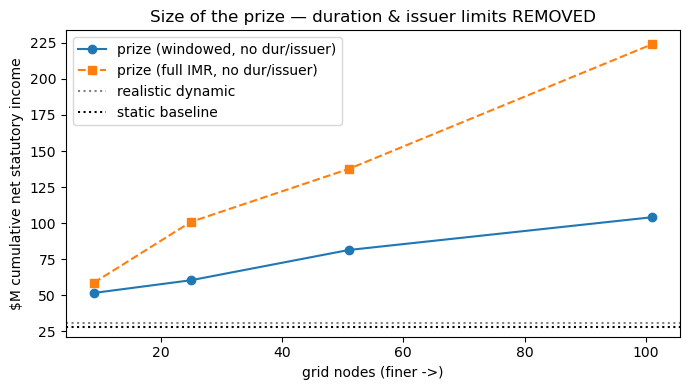

In [ ]:
# %%
# ===========================================================================
# Grid-sensitivity sweep — duration band AND issuer concentration cap REMOVED
# (enforce=False drops both; capital cost + budget/book-value conservation stay)
# ===========================================================================
import time
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for label, grid in [("quarterly", build_grid_every(63)),
                    ("monthly",   build_grid("MS")),
                    ("biweekly",  build_grid_every(10)),
                    ("weekly",    build_grid_every(5))]:
    t0 = time.time()
    d, s, a = run_grid(grid, enforce=False)          # <-- no duration band, no issuer cap
    rows.append(dict(grid=label, nodes=len(grid), arcs=a["n_arcs"],
                     prize_window_M=d["prize_window"]/1e6, prize_full_M=d["prize_full"]/1e6,
                     static_M=s["prize_window"]/1e6))
    print(f"{label:9s} nodes={len(grid):3d}  window=${d['prize_window']/1e6:6.1f}M  "
          f"full=${d['prize_full']/1e6:6.1f}M  ({time.time()-t0:.0f}s)")

sweep_unconstrained = pd.DataFrame(rows)
display(sweep_unconstrained)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(sweep_unconstrained["nodes"], sweep_unconstrained["prize_window_M"], "o-", label="prize (windowed, no dur/issuer)")
ax.plot(sweep_unconstrained["nodes"], sweep_unconstrained["prize_full_M"], "s--", label="prize (full IMR, no dur/issuer)")
ax.axhline(DYNAMIC_REF/1e6, color="grey", ls=":", label="realistic dynamic")
ax.axhline(STATIC_REF/1e6, color="black", ls=":", label="static baseline")
ax.set_xlabel("grid nodes (finer ->)")
ax.set_ylabel("$M cumulative net statutory income")
ax.set_title("Size of the prize — duration & issuer limits REMOVED")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# %%
# ===========================================================================
# Cost of limits — side-by-side comparison (Constrained vs Unconstrained)
# ===========================================================================
import time
import pandas as pd

rows = []
for label, grid in [("quarterly", build_grid_every(63)),
                    ("monthly",   build_grid("MS")),
                    ("biweekly",  build_grid_every(10)),
                    ("weekly",    build_grid_every(5))]:
    t0 = time.time()
    d_con, _, a = run_grid(grid, enforce=True)       # all constraints
    d_unc, _, _ = run_grid(grid, enforce=False)      # no duration / no issuer
    rows.append(dict(grid=label, nodes=len(grid),
                     constrained_M=d_con["prize_window"]/1e6,
                     unconstrained_M=d_unc["prize_window"]/1e6,
                     cost_of_limits_M=(d_unc["prize_window"]-d_con["prize_window"])/1e6))
    print(f"{label:9s}  constrained=${d_con['prize_window']/1e6:6.1f}M  "
          f"unconstrained=${d_unc['prize_window']/1e6:6.1f}M  "
          f"cost_of_limits=${(d_unc['prize_window']-d_con['prize_window'])/1e6:5.1f}M  ({time.time()-t0:.0f}s)")

sweep_cmp = pd.DataFrame(rows)
display(sweep_cmp)

quarterly  constrained=$  36.2M  unconstrained=$  51.7M  cost_of_limits=$ 15.5M  (1s)
monthly    constrained=$  42.0M  unconstrained=$  60.5M  cost_of_limits=$ 18.5M  (11s)
biweekly   constrained=$  47.1M  unconstrained=$  81.4M  cost_of_limits=$ 34.4M  (84s)
weekly     constrained=$  54.0M  unconstrained=$ 104.1M  cost_of_limits=$ 50.1M  (641s)


,grid,nodes,constrained_M,unconstrained_M,cost_of_limits_M
0,quarterly,9,36.207299,51.677710,15.470411
1,monthly,25,41.987089,60.475471,18.488382
2,biweekly,51,47.071569,81.426830,34.355260
3,weekly,101,54.002524,104.132256,50.129732


In [13]:
#%% TEST A — BID/ASK SPREAD SENSITIVITY (weekly grid)
# ==============================================================================
# Live market half-spread = TAU (=(ask-bid)/(2*mid)).  Scale it 0/25/50/75/100%
# to see how much of the prize the spread eats.  100% = live, 0% = frictionless
# ceiling.  Weekly grid keeps runtime modest (same finest point as the sweep).
# ==============================================================================

SPREAD_GRID = build_grid_every(5)               # weekly
_sinp = make_inputs(SPREAD_GRID)

def run_grid_spread(grid, inp, tau_mult, enforce=True):
    """run_grid, but multiply the live half-spread TAU by `tau_mult`."""
    TAU_use = TAU * float(tau_mult)
    common = dict(grid=grid, t_grid=inp["t_grid"], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU_use,
                  THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
                  fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS["allow_post_fabn"])
    arcs_d = pf.build_arcs(**common)
    arcs_s = pf.build_arcs(**common, buy_nodes={0})
    sv = dict(H=H, P=inp["P"], N=N, DUR_grid=inp["DUR_grid"], d_fabn_grid=inp["d_fabn_grid"],
              issuer_groups=issuer_groups, eps_D=PARAMS["eps_D"], dur_pen=PARAMS["dur_pen"],
              delta_iss=PARAMS["delta_iss"], enforce_duration=enforce, enforce_issuer=enforce,
              facility=None, env=GENV)
    return pf.solve_prize(arcs_d, **sv), pf.solve_prize(arcs_s, **sv)

spread_rows = []
for pct in (0, 25, 50, 75, 100):
    d, s = run_grid_spread(SPREAD_GRID, _sinp, pct/100.0)
    assert d["status"] == "OPTIMAL", f"spread {pct}%: {d['status']}"
    dc = d["decomp"]
    spread_rows.append(dict(
        spread_pct        = pct,
        label             = f"{pct}%" + (" (live)" if pct == 100 else ""),
        prize_window_M    = d["prize_window"] / 1e6,
        prize_full_M      = d["prize_full"]   / 1e6,
        static_M          = s["prize_window"] / 1e6,
        gap_vs_static_M   = (d["prize_window"] - s["prize_window"]) / 1e6,
        txn_cost_M        = dc["cost"]        / 1e6,
        imr_window_M      = dc["imr_window"]  / 1e6,
        traded_notional_M = d["traded_notional"] / 1e6,
    ))
spread = pd.DataFrame(spread_rows)
_p0 = spread.loc[spread.spread_pct == 0, "prize_window_M"].iloc[0]          # frictionless
spread["pct_of_frictionless"] = (100 * spread["prize_window_M"] / _p0).round(1)

print("BID/ASK SPREAD SENSITIVITY  (weekly grid)")
display(spread.round(2))
print(f"\nLive (100%) keeps {spread.loc[spread.spread_pct==100,'pct_of_frictionless'].iloc[0]:.0f}% "
      f"of the frictionless (0%) prize; "
      f"spread costs ${(_p0 - spread.loc[spread.spread_pct==100,'prize_window_M'].iloc[0]):.1f}M.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(spread["spread_pct"], spread["prize_window_M"], "o-",  label="prize (windowed)")
ax.plot(spread["spread_pct"], spread["prize_full_M"],   "s--", label="prize (full IMR)")
ax.plot(spread["spread_pct"], spread["txn_cost_M"],     "^:",  color="purple", label="txn cost paid")
ax.axvline(100, color="grey", ls=":", lw=1)
ax.annotate(" live", (100, ax.get_ylim()[1]), va="top", fontsize=8, color="grey")
ax.set_xlabel("bid/ask half-spread applied (% of live)")
ax.set_ylabel("$M cumulative net statutory income")
ax.set_title("Prize vs bid/ask spread (weekly grid)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

KeyboardInterrupt: 

In [ ]:
#%% TEST B — TURNOVER (TRADING-VOLUME) CAP (weekly grid)
# ==============================================================================
# How much churn does the prize actually need?  Cap total *traded notional*
# (= Σ dollars through arcs SOLD before maturity — the SAME quantity solve_prize
#  returns as `traded_notional`) at 1x / 2x / 5x / unlimited of book value H.
# 1x ≈ deploy once, barely flip;  unlimited = live headline.
# solve_prize has no turnover knob, so this cell adds ONE constraint on top of an
# EXACT copy of its model (the module is untouched).  We assert the uncapped copy
# reproduces the real engine, so the capped numbers are trustworthy.
# ==============================================================================

import gurobipy as gp
from gurobipy import GRB

TURN_GRID = build_grid_every(5)                 # weekly, same as Test A
_tinp = make_inputs(TURN_GRID)
_tcommon = dict(grid=TURN_GRID, t_grid=_tinp["t_grid"], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU,
                THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
                fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS["allow_post_fabn"])
ARCS_T = pf.build_arcs(**_tcommon)
_SV = dict(H=H, P=_tinp["P"], N=N, DUR_grid=_tinp["DUR_grid"], d_fabn_grid=_tinp["d_fabn_grid"],
           issuer_groups=issuer_groups, eps_D=PARAMS["eps_D"], dur_pen=PARAMS["dur_pen"],
           delta_iss=PARAMS["delta_iss"], enforce_duration=True, enforce_issuer=True,
           facility=None, env=GENV)

def solve_prize_turnover(arcs, turnover_cap=None, *, H, P, N, DUR_grid, d_fabn_grid,
                         issuer_groups, eps_D, dur_pen, delta_iss,
                         enforce_duration, enforce_issuer, facility, env):
    """EXACT copy of pf.solve_prize's model + ONE optional constraint:
         Σ_{sold arcs} x_a <= turnover_cap     (matches `traded_notional`).
    facility is accepted for signature parity but ignored (headline = facility off)."""
    na = arcs["n_arcs"]
    m = gp.Model("prize_turnover", env=env) if env is not None else gp.Model("prize_turnover")
    m.Params.OutputFlag = 0
    m.Params.DualReductions = 0
    x = m.addVars(na, lb=0.0)
    
    # --- book-value conservation (time-expanded flow) ---
    buys_at  = [gp.LinExpr() for _ in range(P)]
    frees_at = [gp.LinExpr() for _ in range(P + 1)]
    for a in range(na):
        buys_at[int(arcs["p_buy"][a])] += x[a]
        cl = int(arcs["p_close"][a])
        if cl <= P:
            frees_at[min(cl, P)] += x[a]
    m.addConstr(buys_at[0] <= float(H))
    running = float(H) - buys_at[0]
    for p in range(1, P):
        running = running + frees_at[p]
        m.addConstr(buys_at[p] <= running)
        running = running - buys_at[p]
        
    # --- per-interval holdings cover ---
    cover = [[] for _ in range(P)]
    for a in range(na):
        for p in range(int(arcs["p_buy"][a]), min(int(arcs["p_close"][a]), P)):
            cover[p].append(a)
            
    # --- soft duration band ---
    breach = gp.LinExpr()
    if enforce_duration and DUR_grid is not None and d_fabn_grid is not None:
        for p in range(P):
            dd = gp.LinExpr()
            for a in cover[p]:
                dd += DUR_grid[p, arcs["i"][a]] * x[a]
            dp = m.addVar(lb=0.0); dn = m.addVar(lb=0.0)
            ep = m.addVar(lb=0.0); en = m.addVar(lb=0.0)
            m.addConstr(dd - d_fabn_grid[p] * H == dp - dn)
            m.addConstr(dp <= eps_D * H + ep)
            m.addConstr(dn <= eps_D * H + en)
            breach += ep + en
            
    # --- issuer concentration cap ---
    if enforce_issuer and issuer_groups:
        for p in range(P):
            present = {}
            for a in cover[p]:
                present.setdefault(arcs["i"][a], []).append(a)
            for grp, members in issuer_groups.items():
                e = gp.LinExpr(); hit = False
                for i in members:
                    if i in present:
                        hit = True
                        for a in present[i]:
                            e += x[a]
                if hit:
                    m.addConstr(e <= delta_iss * H)
                    
    # >>> the ONE added constraint: turnover (traded-notional) cap <<<
    if turnover_cap is not None:
        m.addConstr(gp.quicksum(x[a] for a in range(na) if arcs["sold"][a]) <= float(turnover_cap))
        
    # --- objective (no facility term; headline) ---
    m.setObjective(gp.quicksum(float(arcs["coef"][a]) * x[a] for a in range(na))
                   - dur_pen * breach, GRB.MAXIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        return {"status": f"GRB_{m.Status}", "prize_window": None}
    xv = np.array([x[a].X for a in range(na)])
    dec = dict(carry=float(np.sum(arcs["carry"] * xv)), capital=float(np.sum(arcs["capital"] * xv)),
               cost=float(np.sum(arcs["cost"] * xv)), imr_window=float(np.sum(arcs["imr_window"] * xv)),
               imr_full=float(np.sum(arcs["imr_full"] * xv)))
    base = dec["carry"] - dec["capital"] - dec["cost"]
    return dict(status="OPTIMAL", prize_window=base + dec["imr_window"],
                prize_full=base + dec["imr_full"], decomp=dec,
                traded_notional=float(np.sum(xv[arcs["sold"]])))

# consistency: my uncapped copy must reproduce the real engine on this grid
_ref = pf.solve_prize(ARCS_T, **_SV)
_chk = solve_prize_turnover(ARCS_T, turnover_cap=None, **_SV)
assert abs(_ref["prize_window"] - _chk["prize_window"]) < 1.0, \
    f"in-cell copy diverged from engine: {_ref['prize_window']:.0f} vs {_chk['prize_window']:.0f}"
print(f"consistency OK: in-cell copy == engine (${_chk['prize_window']/1e6:.2f}M windowed)\n")

turn_rows = []
for label, mult in [("1x book", 1.0), ("2x book", 2.0), ("5x book", 5.0), ("unlimited (live)", None)]:
    cap = None if mult is None else mult * H
    r = solve_prize_turnover(ARCS_T, turnover_cap=cap, **_SV)
    assert r["status"] == "OPTIMAL", f"{label}: {r['status']}"
    dc = r["decomp"]
    turn_rows.append(dict(
        cap               = label,
        cap_xbook         = (mult if mult is not None else np.inf),
        prize_window_M    = r["prize_window"] / 1e6,
        prize_full_M      = r["prize_full"]   / 1e6,
        carry_M           = dc["carry"]       / 1e6,
        imr_window_M      = dc["imr_window"]  / 1e6,
        txn_cost_M        = dc["cost"]        / 1e6,
        traded_notional_M = r["traded_notional"] / 1e6,
        turnover_x        = r["traded_notional"] / H,
    ))
turnover = pd.DataFrame(turn_rows)
_pmax = turnover["prize_window_M"].iloc[-1]      # unlimited row
turnover["pct_of_unlimited"] = (100 * turnover["prize_window_M"] / _pmax).round(1)
# the unlimited copy must equal the real engine (sanity)
assert abs(_pmax - _ref["prize_window"] / 1e6) < 1e-3

print("TURNOVER (TRADED-NOTIONAL) CAP SENSITIVITY  (weekly grid)")
display(turnover.round(2))
print(f"\nAt just 1x book turnover you already capture "
      f"{turnover['pct_of_unlimited'].iloc[0]:.0f}% of the unlimited prize; "
      f"the jump from 2x→unlimited adds only "
      f"${_pmax - turnover['prize_window_M'].iloc[1]:.1f}M.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
_xpos = np.arange(len(turnover))
ax.bar(_xpos, turnover["prize_window_M"], color="#1976D2", alpha=0.85)
for _i, (_p, _t) in enumerate(zip(turnover["prize_window_M"], turnover["turnover_x"])):
    ax.text(_i, _p + 0.3, f"${_p:.1f}M\n{_t:.1f}x", ha="center", va="bottom", fontsize=8)
ax.set_xticks(_xpos); ax.set_xticklabels(turnover["cap"])
ax.set_ylabel("$M cumulative net statutory income")
ax.set_title("Prize vs turnover cap (weekly grid)\n(label shows realized turnover ×book)")
ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()